# Prompt Battle for VLM — 멀티모달 프롬프트 엔지니어링 실습

동일 MVTec AD 이미지에 **5가지 프롬프트 기법**을 적용하고 **Qwen3-VL** 응답 품질을 비교·평가하는 교육용 실습 시스템입니다.

| 항목 | 내용 |
|------|------|
| VLM | Qwen3-VL-4B-Instruct (Hugging Face Transformers) |
| 데이터 | MVTec AD — screw, metal_nut |
| 평가 | OpenAI GPT (1~10점) |
| UI | Gradio |

### 13단계 실습 구성

| § | 내용 |
|---|------|
| 1 | 환경 설정 |
| 2 | MVTec AD 데이터셋 |
| 3 | Qwen3-VL 모델 로드 |
| 4 | 프롬프트 템플릿 |
| 5 | VLM 추론 엔진 |
| 6 | 5가지 프롬프트 실행 |
| 7 | 결과 비교 테이블 |
| 8 | GPT 자동 평가 |
| 9 | matplotlib 시각화 |
| 10 | Gradio UI |
| 11 | 교육용 분석 |
| 12 | 통합 파이프라인 |
| 13 | 요약 및 확장 |


## 1. 환경 설정

```bash
pip install -r requirements.txt
```

| 패키지 | 용도 |
|--------|------|
| `transformers>=4.57.0` | Qwen3-VL |
| `gradio` | 웹 UI |
| `openai` | GPT 평가 |
| `matplotlib` | 점수 차트 |

<br>

> **OpenAI API**: `C:\\env\\.env` 파일의 `OPENAI_API_KEY`가 자동 로드됩니다.



In [ ]:
# %pip install -q "transformers>=4.57.0" accelerate pillow matplotlib openai pandas
# Gradio 웹 UI 패키지 설치 (§10 Gradio UI에서 사용)
%pip install gradio


In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import torch
from IPython.display import Markdown, display

# ── 프로젝트 루트 탐색 ──
# 노트북 실행 위치(cwd)가 프로젝트 루트가 아닐 수 있어 prompt_battle 패키지를 찾는다.
ROOT = Path.cwd()
if not (ROOT / "prompt_battle").exists():
    for parent in [ROOT, *ROOT.parents]:
        if (parent / "prompt_battle").exists():
            ROOT = parent
            break
# 패키지 import 경로에 프로젝트 루트 추가
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from prompt_battle.config import BattleConfig
from prompt_battle.dataset import find_project_root
from prompt_battle.env_loader import load_env_file, openai_api_key_configured

# MVTec zip·데이터가 있는 실제 프로젝트 루트
ROOT = find_project_root()
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
config = BattleConfig()
# C:\env\.env 에서 OPENAI_API_KEY 자동 로드
load_env_file(config.env_file)

# 환경 확인 출력
print(f"ROOT   : {ROOT}")
print(f"Device : {DEVICE}")
print(f"Model  : {config.qwen_model_id}")
print(f"GPT    : {config.gpt_model}")
print(f"Env    : {config.env_file}")
print(f"OPENAI_API_KEY 설정: {openai_api_key_configured()}")


c:\Users\storm\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch\cuda\__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


ROOT   : c:\MyCursorLab\07_Vision_Language_Model
Device : cuda
Model  : Qwen/Qwen3-VL-4B-Instruct
GPT    : gpt-4o-mini
Env    : C:\env\.env
OPENAI_API_KEY 설정: True


## 2. MVTec AD 데이터셋 탐색

screw · metal_nut 카테고리의 test 이미지를 사용합니다.



[screw] 총 160장 — {'good': 41, 'manipulated_front': 24, 'scratch_head': 24, 'scratch_neck': 25, 'thread_side': 23, 'thread_top': 23}
[metal_nut] 총 115장 — {'bent': 25, 'color': 22, 'flip': 23, 'good': 22, 'scratch': 23}

샘플 이미지: c:\MyCursorLab\07_Vision_Language_Model\MVTec_screw_metal_nut\MVTec_screw_metal_nut\screw\test\good\000.png
Ground Truth: good


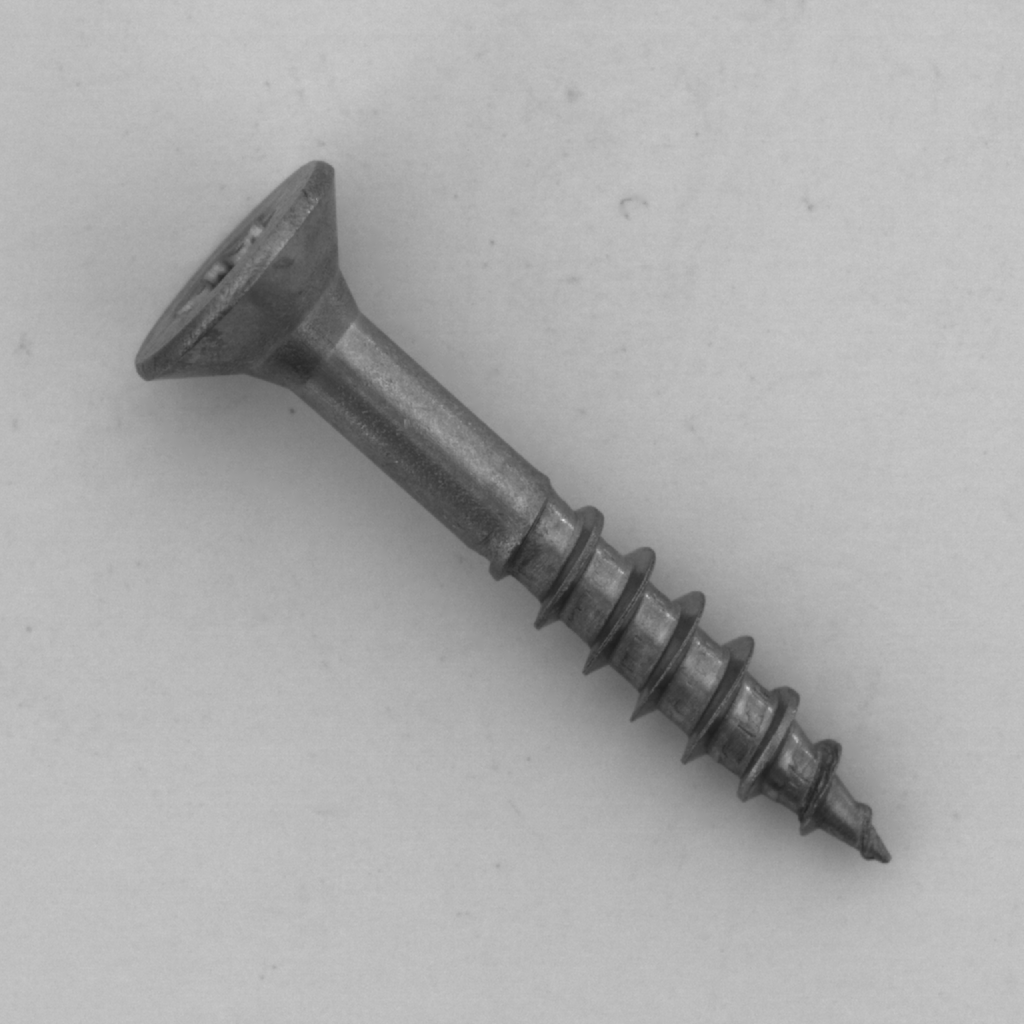

In [2]:
from prompt_battle.dataset import (
    dataset_summary,
    extract_mvtec_zip,
    list_test_images,
    ground_truth_defect,
)
from PIL import Image

# MVTec AD 데이터 경로 (screw, metal_nut)
DATA_ROOT = ROOT / "MVTec_screw_metal_nut"
ZIP_PATH = ROOT / "MVTec_screw_metal_nut.zip"

# zip 압축 해제 (이미 있으면 스킵)
extract_mvtec_zip(ZIP_PATH, DATA_ROOT, config.categories)
summary = dataset_summary(DATA_ROOT, config.categories)

# 카테고리별 결함 유형·이미지 수 출력
for cat, defects in summary.items():
    total = sum(defects.values())
    print(f"[{cat}] 총 {total}장 — {defects}")

# 이후 셀에서 공통으로 사용할 샘플 이미지 1장 선택
SAMPLE_IMAGE = list_test_images(DATA_ROOT, "screw")[0]
print(f"\n샘플 이미지: {SAMPLE_IMAGE}")
print(f"Ground Truth: {ground_truth_defect(SAMPLE_IMAGE)}")  # 폴더명 = 정답 결함 유형
display(Image.open(SAMPLE_IMAGE))


## 3. Qwen3-VL 모델 로드

Hugging Face Transformers로 Qwen3-VL을 GPU에 로드합니다.


In [3]:
from prompt_battle.vlm import Qwen3VLEngine

# Qwen3-VL-4B-Instruct 프로세서·모델 로드 (GPU 사용 가능 시 CUDA)
engine = Qwen3VLEngine(config)
engine.load()
print(f"모델 로드 완료 — device: {engine.device}, dtype: {engine.dtype}")


Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/713 [00:00<?, ?it/s]

모델 로드 완료 — device: cuda, dtype: torch.bfloat16


## 4. 프롬프트 템플릿 정의

동일 이미지에 적용할 5가지 프롬프트 기법입니다.


In [4]:
from prompt_battle.prompts import ALL_PROMPTS

# 5가지 프롬프트 기법 템플릿 확인 (Basic / Role / JSON / CoT / Risk)
for i, prompt in enumerate(ALL_PROMPTS, 1):
    print(f"--- {i}. {prompt.display_name} ({prompt.key}) ---")
    print(prompt.text)
    print()


--- 1. Basic (basic) ---
이미지를 분석하라.

--- 2. Role (role) ---
당신은 제조업 품질관리 엔지니어이다.
제품 종류와 결함 여부를 분석하라.

--- 3. JSON (json) ---
이미지를 분석하고 JSON 형식으로 출력하라.

{
  "product":"",
  "defect":"",
  "location":"",
  "severity":""
}

--- 4. CoT (cot) ---
이미지를 분석하라.

1. 제품 종류 식별
2. 특징 분석
3. 결함 여부 판단
4. 결함 근거 설명
5. 최종 결론 작성

--- 5. Risk Assessment (risk) ---
당신은 품질보증 책임자이다.

1. 결함 유형
2. 위험도
3. 출하 가능 여부
4. 권장 조치

를 작성하라.



## 5. VLM 추론 엔진

단일 이미지·프롬프트에 대한 Qwen3-VL 추론을 수행합니다.


In [5]:
from prompt_battle.prompts import BASIC_PROMPT

# 단일 프롬프트(Basic)로 VLM 추론 테스트
sample_img = Image.open(SAMPLE_IMAGE).convert("RGB")
result = engine.run_prompt(sample_img, BASIC_PROMPT.key, BASIC_PROMPT.display_name, BASIC_PROMPT.text)

print(f"프롬프트: {result.prompt_display_name}")
print(f"응답 길이: {result.response_length} | 소요: {result.response_time_sec}s")
print("\n=== 응답 ===")
print(result.response)


프롬프트: Basic
응답 길이: 857 | 소요: 49.2s

=== 응답 ===
이 이미지는 **흑백 사진**으로, **하나의 나사**를 중심으로 촬영한 것으로 보입니다. 아래에 구체적인 분석을 제공합니다.

---

### 📷 **1. 주요 대상: 나사**
- **형태**: 나사의 전체 구조가 선명하게 보입니다.
  - **머리**: 평면형(또는 약간의 경사형)의 **드라이버 머리**로, **사각형 또는 복합형**의 구멍이 있는 것으로 보입니다. (사각형은 일반적으로 허리케인형, 복합형은 일반적으로 드라이버형)
  - **몸통**: 나사의 몸통은 **직선형**이며, **조금 굴곡진 형태**를 가지고 있습니다.
  - **조각**: 나사의 **조각**은 **정확한 형태**로, **정확한 구조**를 가지고 있습니다.
  - **끝**: 나사의 **끝**은 **정확한 형태**로, **정확한 구조**를 가지고 있습니다.

---

### 📷 **2. 배경**
- **배경**: **단색의 평면 배경**으로, **흰색 또는 회색**으로 보입니다.
- **특징**: 배경은 **단순하고 깨끗한** 상태로, **나사의 형태**를 강조합니다.

---

### 📷 **3. 촬영 기술**
- **조명**: **직접 조명**으로, **나사의 표면**에 **명확한 그림자**가 생기며, **표면의 질감**을 잘 드러냅니다.
- **각도**: **나사의 각도**는 **약간의 기울기**를 가지고 있으며, **나사의 형태**를 잘 보여줍니다.
- **해상도**: **높은 해상도**로, **나사의 세부 구조**를 잘 보여줍니다.

---

### 📷 **4. 분석 결과**
- **나사의 형태**: **정확한 형태**로, **정확한 구조**를 가지고 있습니다.
- **배경**: **단순하고 깨끗한** 상태로, **나사의


## 6. 5가지 프롬프트 자동 실행

선택 이미지에 5가지 프롬프트를 순차 적용합니다.


In [6]:
from prompt_battle.prompts import ALL_PROMPTS

# 동일 이미지에 5가지 프롬프트 순차 적용
image = Image.open(SAMPLE_IMAGE).convert("RGB")
inference_results = []

for prompt in ALL_PROMPTS:
    r = engine.run_prompt(image, prompt.key, prompt.display_name, prompt.text)
    inference_results.append(r)
    print(f"[{r.prompt_display_name}] {r.response_length} chars, {r.response_time_sec}s")

# RTX 3060 : 약 3분 소요 


[Basic] 857 chars, 48.06s
[Role] 900 chars, 47.77s
[JSON] 76 chars, 3.75s
[CoT] 682 chars, 46.9s
[Risk Assessment] 832 chars, 47.34s


## 7. 결과 비교 테이블

응답 길이·시간·결함·결론을 표로 비교합니다.


In [7]:
from prompt_battle.comparison import build_comparison_rows, rows_to_markdown_table

# 응답 길이·시간·결함·결론 비교 테이블 생성
comparison_rows = build_comparison_rows(inference_results)
display(Markdown(rows_to_markdown_table(comparison_rows)))


| Prompt Type | Response Length | Response Time (s) | Detected Defect | Final Conclusion |
|---|---:|---:|---|---|
| Basic | 857 | 48.06 | 미확인 | - **배경**: **단순하고 깨끗한** 상태로, **나사의 |
| Role | 900 | 47.77 | 정상/결함 없음 | - **검사 시스템**: **공작물 없는 나사** 형태로, **공작물 없는 나사** 형태로 제조되어 있어 |
| JSON | 76 | 3.75 | 결함 감지됨 | screw |
| CoT | 682 | 46.90 | 미확인 | - **몸체**: **조금 굴곡진 측면을 가진 스크루**로, **조금 굴곡진 측면을 가진 스크루**로, **조금 굴곡진 측면을 가진 스크루**로, **조금 굴곡진 측면을 가진 스크루**로, **조금 굴곡진 측면을 가 |
| Risk Assessment | 832 | 47.34 | 정상/결함 없음 | 고객 통지 (필요 시)** |


In [8]:
# §6 추론 결과 원본 객체 확인 (디버깅·탐색용)
inference_results


[InferenceResult(prompt_key='basic', prompt_display_name='Basic', prompt_text='이미지를 분석하라.', response='이 이미지는 **흑백 사진**으로, **하나의 나사**를 중심으로 촬영한 것으로 보입니다. 아래에 구체적인 분석을 제공합니다.\n\n---\n\n### 📷 **1. 주요 대상: 나사**\n- **형태**: 나사의 전체 구조가 선명하게 보입니다.\n  - **머리**: 평면형(또는 약간의 경사형)의 **드라이버 머리**로, **사각형 또는 복합형**의 구멍이 있는 것으로 보입니다. (사각형은 일반적으로 허리케인형, 복합형은 일반적으로 드라이버형)\n  - **몸통**: 나사의 몸통은 **직선형**이며, **조금 굴곡진 형태**를 가지고 있습니다.\n  - **조각**: 나사의 **조각**은 **정확한 형태**로, **정확한 구조**를 가지고 있습니다.\n  - **끝**: 나사의 **끝**은 **정확한 형태**로, **정확한 구조**를 가지고 있습니다.\n\n---\n\n### 📷 **2. 배경**\n- **배경**: **단색의 평면 배경**으로, **흰색 또는 회색**으로 보입니다.\n- **특징**: 배경은 **단순하고 깨끗한** 상태로, **나사의 형태**를 강조합니다.\n\n---\n\n### 📷 **3. 촬영 기술**\n- **조명**: **직접 조명**으로, **나사의 표면**에 **명확한 그림자**가 생기며, **표면의 질감**을 잘 드러냅니다.\n- **각도**: **나사의 각도**는 **약간의 기울기**를 가지고 있으며, **나사의 형태**를 잘 보여줍니다.\n- **해상도**: **높은 해상도**로, **나사의 세부 구조**를 잘 보여줍니다.\n\n---\n\n### 📷 **4. 분석 결과**\n- **나사의 형태**: **정확한 형태**로, **정확한 구조**를 가지고 있습니다.\n- **배경**: **단순하고 깨끗한** 상태로, **나사의', response_l

## 8. GPT 자동 평가

OpenAI GPT가 5가지 기준(정보량·정확성·구조화·추론·실무 활용성)으로 1~10점을 부여합니다.

> OpenAI API 키는 `C:\\env\\.env`의 `OPENAI_API_KEY`에서 자동 로드됩니다. 미설정 시 휴리스틱 평가로 대체됩니다.



In [9]:
from prompt_battle.evaluation import evaluate_prompts

# OpenAI GPT로 5가지 기준 1~10점 평가 (API 키 없으면 휴리스틱 폴백)
gt = ground_truth_defect(SAMPLE_IMAGE)
evaluation = evaluate_prompts(
    inference_results,
    comparison_rows,
    ground_truth_defect=gt,
    model=config.gpt_model,
)

print(evaluation.score_table_markdown())
mode = "GPT" if evaluation.used_gpt else "휴리스틱"
print(f"\n평가 방식: {mode}")


----------------------------------------------------
Prompt Type      Score
----------------------------------------------------
Basic              5
Role               7
JSON               5
CoT                8
Risk Assessment    9
----------------------------------------------------
Best Prompt : Risk Assessment
----------------------------------------------------

평가 방식: GPT


## 9. matplotlib 시각화

프롬프트 유형별 평가 점수를 막대그래프로 표시합니다.


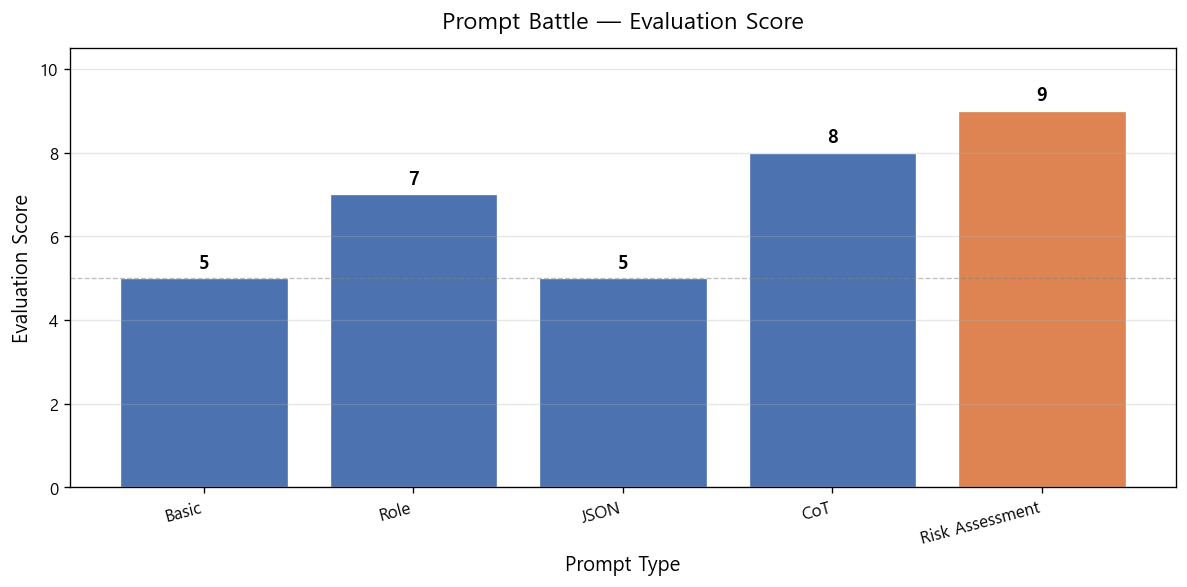

In [10]:
from prompt_battle.visualization import plot_evaluation_scores

# 프롬프트 유형별 평가 점수 막대그래프
fig = plot_evaluation_scores(evaluation, title="Prompt Battle — Evaluation Score")
plt.show()


## 10. Gradio UI

좌측: 이미지 선택 + 실행 / 우측: 결과·테이블·차트

> **속도 팁**: 커널 재시작 후 §1 → §10만 실행 · 프롬프트별 결과가 순차 표시됨 · GPT 평가는 필요 시만 체크


In [ ]:
# 노트북에서 Gradio 실행
# ※ §3 engine 공유 시 VRAM 중복 방지 / §10만: 커널 재시작 → §1 → §10 권장
import torch
from prompt_battle.gradio_app import build_demo, register_engine

try:
    # §3에서 로드한 engine이 있으면 Gradio와 공유 (모델 2중 로드 방지)
    register_engine(engine)  # noqa: F821 — §3 실행 시 존재
    print("노트북 engine 공유 — 중복 모델 로드 방지")
except NameError:
    # §3를 건너뛰고 §10만 실행한 경우: VRAM 정리 후 Gradio에서 선로드
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    print("새 engine 사용 — Gradio 시작 시 모델 선로드")

demo = build_demo()
demo.launch(share=False)
# RTX 3060 : 약 3~5분


노트북 engine 공유 — 중복 모델 로드 방지
* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.


c:\Users\storm\AppData\Local\Programs\Python\Python311\Lib\site-packages\gradio\routes.py:1379: StarletteDeprecationWarning: 'HTTP_422_UNPROCESSABLE_ENTITY' is deprecated. Use 'HTTP_422_UNPROCESSABLE_CONTENT' instead.
  return await queue_join_helper(body, request, username)
c:\Users\storm\AppData\Local\Programs\Python\Python311\Lib\site-packages\gradio\routes.py:1379: StarletteDeprecationWarning: 'HTTP_422_UNPROCESSABLE_ENTITY' is deprecated. Use 'HTTP_422_UNPROCESSABLE_CONTENT' instead.
  return await queue_join_helper(body, request, username)


## 11. 교육용 분석

프롬프트 비교 결과를 바탕으로 자동 설명을 생성합니다.


In [12]:
from prompt_battle.education import generate_educational_insights, insights_to_markdown

# 평가 결과 기반 교육용 자동 설명 생성
insights = generate_educational_insights(evaluation)
display(Markdown(insights_to_markdown(insights)))


### 교육용 분석

- Role Prompt는 기본 프롬프트보다 더 상세한 품질 분석 결과를 생성하였다.
- Risk Assessment Prompt는 출하 판정·권장 조치 등 실무 QA 관점의 정보를 제공한다.
- 이번 Prompt Battle에서 최고 점수를 받은 프롬프트는 **Risk Assessment** (점수 9/10)이다.

## 12. 통합 파이프라인

`PromptBattle` 클래스로 전체 워크플로를 한 번에 실행합니다.


### 비교 테이블
| Prompt Type | Response Length | Response Time (s) | Detected Defect | Final Conclusion |
|---|---:|---:|---|---|
| Basic | 857 | 47.36 | 미확인 | - **배경**: **단순하고 깨끗한** 상태로, **나사의 |
| Role | 900 | 53.71 | 정상/결함 없음 | - **검사 시스템**: **공작물 없는 나사** 형태로, **공작물 없는 나사** 형태로 제조되어 있어 |
| JSON | 76 | 3.86 | 결함 감지됨 | screw |
| CoT | 682 | 48.95 | 미확인 | - **몸체**: **조금 굴곡진 측면을 가진 스크루**로, **조금 굴곡진 측면을 가진 스크루**로, **조금 굴곡진 측면을 가진 스크루**로, **조금 굴곡진 측면을 가진 스크루**로, **조금 굴곡진 측면을 가 |
| Risk Assessment | 832 | 45.89 | 정상/결함 없음 | 고객 통지 (필요 시)** |


### 평가 점수
----------------------------------------------------
Prompt Type      Score
----------------------------------------------------
Basic              5
Role               7
JSON               4
CoT                7
Risk Assessment    9
----------------------------------------------------
Best Prompt : Risk Assessment
----------------------------------------------------

### 교육용 분석

- Role Prompt는 기본 프롬프트보다 더 상세한 품질 분석 결과를 생성하였다.
- Risk Assessment Prompt는 출하 판정·권장 조치 등 실무 QA 관점의 정보를 제공한다.
- 이번 Prompt Battle에서 최고 점수를 받은 프롬프트는 **Risk Assessment** (점수 9/10)이다.

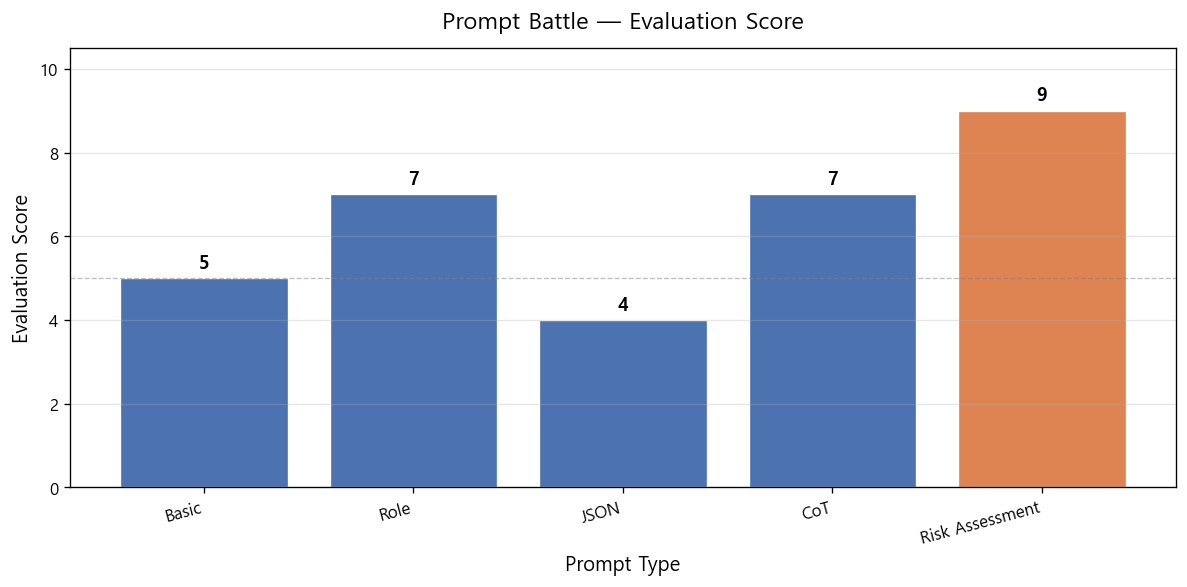

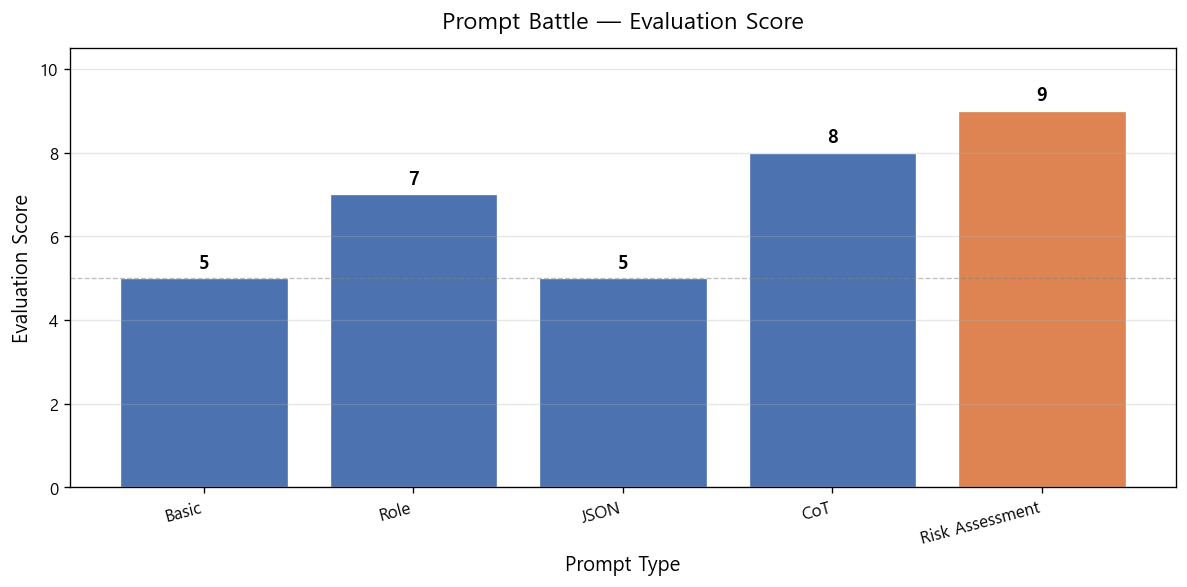

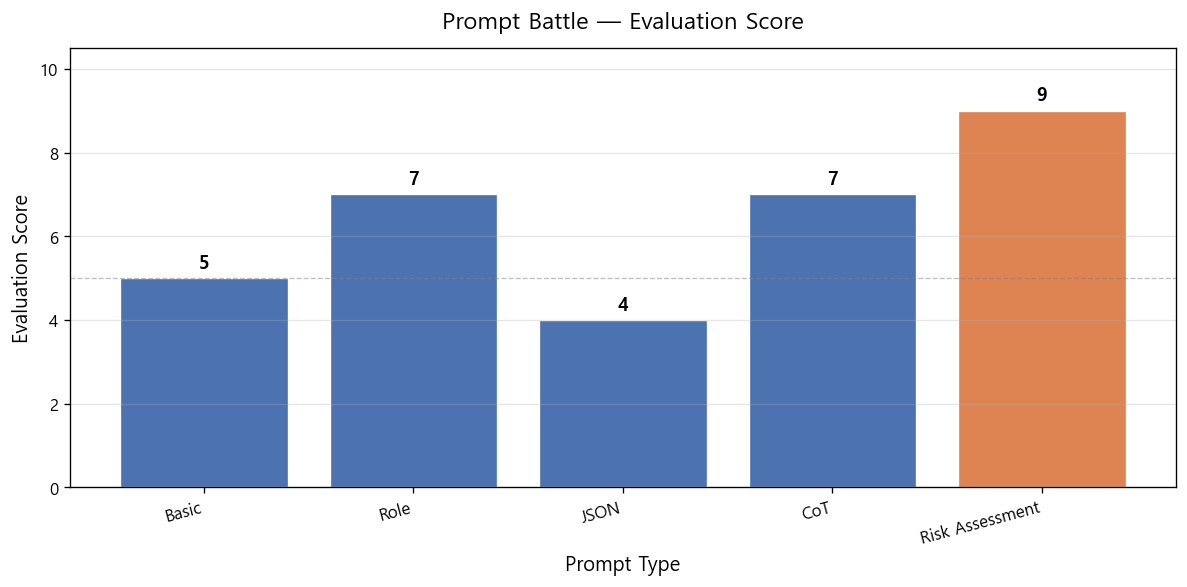

In [ ]:
from prompt_battle.battle import PromptBattle

# PromptBattle 클래스로 VLM 추론→비교→평가→저장 일괄 실행
battle = PromptBattle(config, root=ROOT)
report = battle.run_battle(SAMPLE_IMAGE, run_gpt_eval=True)

display(Markdown("### 비교 테이블\n" + report.comparison_markdown()))
display(Markdown("### 평가 점수\n" + report.score_markdown()))
display(Markdown(report.education_markdown()))

# 저장된 평가 차트 PNG 표시
if report.chart_path:
    display(Image.open(report.chart_path))
#RTX 3060 : 약 3.5분 소요

## 13. 요약 및 확장

### 학습 포인트

1. **Basic Prompt** — 최소 지시, 응답이 짧고 일반적
2. **Role Prompt** — 도메인 역할 부여로 품질 분석 맥락 강화
3. **JSON Prompt** — 구조화 출력, 자동화·파싱에 유리
4. **Chain of Thought** — 단계별 추론으로 설명력 극대화
5. **Risk Assessment** — 실무 QA 관점(위험도·출하·조치)

### 확장 아이디어

- QLoRA 파인튜닝 모델과 베이스 모델 Prompt Battle 비교 (`12_` 노트북 참고)
- 프롬프트 변형 A/B 테스트 자동화
- 배치 이미지 평가 및 리더보드

---

### `prompt_battle/` 소스 구조 및 기능

| 파일 | 주요 클래스·함수 | 기능 |
|------|-----------------|------|
| `__init__.py` | `PromptBattle`, `BattleConfig`, `Qwen3VLEngine` | 패키지 진입점. import 시 `C:\\env\\.env` 자동 로드 |
| `__main__.py` | `launch()` | `python -m prompt_battle` CLI 실행 진입점 |
| `config.py` | `BattleConfig` | Qwen3-VL·GPT·MVTec·출력 경로 등 전역 설정 |
| `env_loader.py` | `load_env_file()`, `get_openai_api_key()` | `.env` 파싱 및 `OPENAI_API_KEY` 주입 |
| `dataset.py` | `extract_mvtec_zip()`, `list_test_images()`, `build_image_choices()` | MVTec zip 해제, 이미지 목록, Gradio 드롭다운 라벨 생성 |
| `prompts.py` | `ALL_PROMPTS`, `PromptTemplate` | 5가지 프롬프트 템플릿 (Basic / Role / JSON / CoT / Risk) |
| `vlm.py` | `Qwen3VLEngine`, `InferenceResult` | Hugging Face Qwen3-VL 추론, engine 공유 (`set_shared_engine`) |
| `comparison.py` | `build_comparison_rows()`, `rows_to_markdown_table()` | VLM 응답 파싱·비교 테이블 생성 |
| `evaluation.py` | `evaluate_prompts()`, `EvaluationReport` | OpenAI GPT 1~10점 평가 (실패 시 휴리스틱 폴백) |
| `visualization.py` | `plot_evaluation_scores()` | matplotlib 막대그래프 (Best Prompt 강조) |
| `education.py` | `generate_educational_insights()` | 평가 결과 기반 교육용 자동 설명 문장 생성 |
| `battle.py` | `PromptBattle`, `BattleReport` | 전체 워크플로 오케스트레이터 (추론→비교→평가→저장) |
| `gradio_app.py` | `build_demo()`, `launch()`, `register_engine()` | Gradio 웹 UI (스트리밍 결과·진행 표시) |

### Gradio UI (`gradio_app.py`) 기능

| UI 영역 | 구성 요소 | 설명 |
|---------|----------|------|
| **좌측** | 이미지 드롭다운 | screw / metal_nut MVTec test 이미지 선택 |
| | 이미지 미리보기 | 선택 이미지 즉시 표시 |
| | GPT 평가 체크박스 | ON 시 OpenAI GPT 평가·차트·교육용 분석 실행 |
| | 실행 버튼 | 5가지 프롬프트 순차 추론 시작 |
| **우측** | VLM 응답 탭 | 프롬프트별 Qwen3-VL 응답 (완료마다 갱신) |
| | 비교 테이블 탭 | Response Length / Time / Defect / Conclusion |
| | 평가 점수 탭 | GPT·휴리스틱 1~10점 요약표 |
| | 평가 차트 탭 | 프롬프트별 점수 막대그래프 |
| | 교육용 분석 | 자동 생성 학습 포인트 문장 |
| **상단** | 상태 메시지 | 모델·OpenAI API 준비 상태, 진행률 표시 |

**Gradio 내부 동작 흐름**

1. 앱 시작 → `preload_model()` 로 Qwen3-VL 선로드
2. 실행 클릭 → `iter_prompt_inferences()` 로 5개 프롬프트 **스트리밍** 추론
3. 각 프롬프트 완료 시 비교 테이블·응답 **즉시 갱신** (`processing` 장시간 대기 완화)
4. 추론 완료 → `finalize_battle()` 로 GPT 평가·차트·JSON 저장
5. 결과 저장 → `outputs/prompt_battle/battle_*.json`, `battle_*.png`

> **VRAM 절약**: §3에서 로드한 `engine`을 `register_engine(engine)`으로 Gradio와 공유하면 모델 2중 로드를 방지한다.

### 소스 사용법

#### 1) 노트북 실습 (권장)

```bash
pip install -r requirements.txt
```

노트북 `13_prompt_battle_for_vlm.ipynb`를 **§1 → §13** 순서로 실행한다.

| 목적 | 실행 범위 |
|------|----------|
| 전체 실습 | §1 ~ §13 |
| Gradio만 빠르게 | 커널 재시작 → §1 → §10 |
| API 키 확인 | §1 출력에서 `OPENAI_API_KEY 설정: True` 확인 |

#### 2) Python 코드에서 직접 사용

```python
from prompt_battle import PromptBattle, BattleConfig

config = BattleConfig()
battle = PromptBattle(config)
report = battle.run_battle("path/to/image.png", run_gpt_eval=True)

print(report.comparison_markdown())
print(report.score_markdown())
```

#### 3) Gradio 웹 UI 실행

```bash
# 방법 A: 모듈 실행
python -m prompt_battle

# 방법 B: 직접 실행
python -m prompt_battle.gradio_app
```

브라우저에서 `http://127.0.0.1:7860` 접속 후 이미지 선택 → **Prompt Battle 실행**.

#### 4) 노트북 내 Gradio 실행

```python
from prompt_battle.gradio_app import build_demo, register_engine

register_engine(engine)  # §3 engine 공유 (선택)
demo = build_demo()
demo.launch(share=False)
```

#### 5) OpenAI API 키 설정

`C:\\env\\.env` 파일에 아래 형식으로 저장 (패키지 import 시 자동 로드):

```
OPENAI_API_KEY=sk-...
```

---

### Google Colab 실행 방법 (`prompt_battle.zip`)

로컬 `prompt_battle/` 패키지와 연동 파일을 압축한 **`prompt_battle.zip`** 을 Colab에 업로드하여 실행한다.

#### `prompt_battle.zip` 권장 구성

```
prompt_battle.zip
├── prompt_battle/          # Python 패키지 전체
│   ├── __init__.py
│   ├── battle.py
│   ├── gradio_app.py
│   └── ...
└── 13_prompt_battle_for_vlm.ipynb   # (선택) 이 노트북 포함 가능
```

> **별도 업로드**: `MVTec_screw_metal_nut.zip` (용량 큼 — zip에 넣지 않고 Colab에 따로 업로드 권장)

#### Colab 실행 순서

| 단계 | 작업 |
|------|------|
| 1 | Colab **런타임 → GPU** 선택 (T4 이상 권장) |
| 2 | `prompt_battle.zip`, `MVTec_screw_metal_nut.zip` 업로드 |
| 3 | 아래 **셋업 코드** 1회 실행 |
| 4 | 노트북 §1 → §13 순서 실행 (Gradio만: §1 → §10) |

#### Colab 셋업 코드 (맨 위 1회 실행)

```python
# GPU 확인
import torch
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")

# 압축 해제
!unzip -q -o prompt_battle.zip -d /content
%cd /content

# 의존성 설치
!pip install -q "transformers>=4.57.0" accelerate pillow matplotlib gradio openai pandas

# OpenAI API 키 (Colab Secrets 사용 권장)
import os
try:
    from google.colab import userdata
    os.environ["OPENAI_API_KEY"] = userdata.get("OPENAI_API_KEY")
    print("OPENAI_API_KEY: Colab Secrets에서 로드")
except Exception:
    os.environ["OPENAI_API_KEY"] = "sk-여기에-키-입력"
    print("OPENAI_API_KEY: 수동 설정")

# 패키지 import 경로
import sys
if "/content" not in sys.path:
    sys.path.insert(0, "/content")
print("셋업 완료")
```

> Colab Secrets: 왼쪽 **열쇠 아이콘** → `OPENAI_API_KEY` 등록 → `userdata.get()` 으로 읽음

#### Colab Gradio 실행

```python
from prompt_battle.gradio_app import build_demo

demo = build_demo()
demo.launch(share=True)   # share=True → 외부 접속 URL 생성
```

#### Colab 주의사항

- 로컬 `C:\\env\\.env` 는 Colab에서 사용 불가 → **Colab Secrets** 또는 `os.environ` 으로 API 키 설정
- Qwen3-VL 최초 실행 시 Hugging Face 모델 다운로드 (~9GB)
- 세션 종료 시 파일 삭제됨 → `prompt_battle.zip` 매 세션 재업로드 필요
- Gradio `share=True` 링크는 72시간 후 만료

